In [ ]:
!pip3 install geopandas shapely shap xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn osmnx optuna category_encoders -q

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import osmnx as ox
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
from category_encoders import TargetEncoder

print("Libraries imported")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
✓ Libraries imported


In [3]:
listings = pd.read_csv('./content/listings.csv')
lsoa_geo = gpd.read_file('./content/LSOA.geojson')

try:
    lsoa_csv = pd.read_csv('./content/LSOA.csv')
except:
    lsoa_csv = None

print(f"Listings: {listings.shape}")
print(f"LSOA: {lsoa_geo.shape}")

Listings: (96182, 75)
LSOA: (5450, 10)


In [4]:
print("=" * 60)
print("LISTINGS — Column Overview")
print("=" * 60)
print(listings.dtypes.to_string())
print(f"\nPrice column sample:\n{listings['price'].head(10)}")
print(f"\nMissing values (top 20):\n{listings.isnull().sum().sort_values(ascending=False).head(20)}")

LISTINGS — Column Overview
id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
name                                             object
description                                      object
neighborhood_overview                            object
picture_url                                      object
host_id                                           int64
host_url                                         object
host_name                                        object
host_since                                       object
host_location                                    object
host_about                                       object
host_response_time                               object
host_response_rate                               object
host_acceptance_rate 

In [ ]:
print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

df = listings.copy()
target_col = 'price'
df[target_col] = df[target_col].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
df = df.dropna(subset=[target_col])
q_low = df[target_col].quantile(0.02)
q_high = df[target_col].quantile(0.98)
df = df[(df[target_col] >= q_low) & (df[target_col] <= q_high)]

df['log_price'] = np.log1p(df[target_col])

print(f"Cleaned data: {df.shape}")
print(f"Price range: ${df[target_col].min():.2f} - EURO{df[target_col].max():.2f}")


DATA PREPROCESSING
Cleaned data: (60827, 76)
Price range: $34.00 - EURO750.00


## Log Transformation

Log transformation is a technique used to make highly skewed data more balanced and easier for models to learn from.

### What it does

Instead of using the raw values, we transform them using:

\[
y = \log(1 + x)
\]


np.log1p(x)

In [ ]:
print("\n" + "="*60)
print("GEOSPATIAL PROCESSING")
print("="*60)

lat_col = [col for col in df.columns if 'latitude' in col.lower()][0]
lon_col = [col for col in df.columns if 'longitude' in col.lower()][0]

df = df.dropna(subset=[lat_col, lon_col])

geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

gdf = gdf.to_crs("EPSG:27700")
lsoa_geo = lsoa_geo.to_crs("EPSG:27700")

gdf_with_lsoa = gpd.sjoin(gdf, lsoa_geo, how='left', predicate='within')

if lsoa_csv is not None:
    lsoa_id_cols = [col for col in lsoa_geo.columns if 'code' in col.lower() or 'id' in col.lower()]
    if lsoa_id_cols:
        lsoa_id = lsoa_id_cols[0]
        gdf_with_lsoa = gdf_with_lsoa.merge(lsoa_csv, on=lsoa_id, how='left', suffixes=('', '_lsoa'))

df = pd.DataFrame(gdf_with_lsoa.drop(columns='geometry'))
print(f"✓ Geospatial join completed")


GEOSPATIAL PROCESSING
✓ Geospatial join completed


In [7]:
print("\n" + "="*60)
print("SPATIAL FEATURES: DISTANCE FROM AIRBNB TO KEY LOCATIONS")
print("="*60)

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in km between two points"""
    R = 6371 
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

key_locations = {
    'city_center': (51.5074, -0.1278),      # Central London
    'heathrow': (51.4700, -0.4543),         # Airport
    'canary_wharf': (51.5054, -0.0235),     # Business district
    'kings_cross': (51.5309, -0.1239),      # Transport hub
    'oxford_street': (51.5155, -0.1419),    # Shopping
}

for location_name, (lat, lon) in key_locations.items():
    df[f'spatial_{location_name}_km'] = haversine_distance(
        df[lat_col], df[lon_col], lat, lon
    )
print(f"Created {len(key_locations)} distance features")

print("\nFetching nearby amenities from OpenStreetMap...")
try:
    ox.settings.use_cache = True
    ox.settings.log_console = False
    pois = ox.features_from_place(
        "Greater London, UK",
        tags={
            "amenity": ["restaurant", "cafe", "pub", "bar", "arts_centre", "theatre"],
            "shop": ["supermarket", "convenience"],
            "public_transport": "station",
            "tourism": ["museum", "attraction", "viewpoint", "gallery"],
            "historic": ["monument", "castle"]
        }
    )


    pois = pois[pois.geometry.notna()].copy()

    if pois.crs != "EPSG:4326":
        pois = pois.to_crs("EPSG:4326")
    pois['centroid'] = pois.geometry.centroid
    poi_coords = np.column_stack([pois['centroid'].x.values, pois['centroid'].y.values])
    poi_tree = cKDTree(poi_coords)
    airbnb_coords = np.column_stack([df[lon_col].values, df[lat_col].values])
    distances, indices = poi_tree.query(airbnb_coords, k=10)

    distances_km = np.zeros_like(distances)
    for i in range(len(airbnb_coords)):
        for j in range(10):
            distances_km[i, j] = haversine_distance(
                airbnb_coords[i, 1], airbnb_coords[i, 0],
                poi_coords[indices[i, j], 1], poi_coords[indices[i, j], 0]
            )

    df['spatial_nearest_amenity_km'] = distances_km[:, 0]
    df['spatial_avg_5_amenities_km'] = distances_km[:, :5].mean(axis=1)
    df['spatial_amenities_500m'] = (distances_km < 0.5).sum(axis=1)
    df['spatial_amenity_density'] = df['spatial_amenities_500m'] / (df['spatial_nearest_amenity_km'] + 0.01)

    print(f"Created 4 POI-based features from {len(pois)} amenities")

except Exception as e:
    print(f"OpenStreetMap fetch failed: {e}")
    print("Using fallback values...")
    df['spatial_nearest_amenity_km'] = 0.5
    df['spatial_avg_5_amenities_km'] = 1.0
    df['spatial_amenities_500m'] = 5
    df['spatial_amenity_density'] = 10

spatial_cols = [c for c in df.columns if c.startswith('spatial_')]
print(f"\n✓ Total spatial features: {len(spatial_cols)}")
print("\nSpatial features created:")
for col in spatial_cols:
    print(f"  - {col}")


SPATIAL FEATURES: DISTANCE FROM AIRBNB TO KEY LOCATIONS
✓ Created 5 distance features

Fetching nearby amenities from OpenStreetMap...
✓ Created 4 POI-based features from 29145 amenities

✓ Total spatial features: 9

Spatial features created:
  - spatial_city_center_km
  - spatial_heathrow_km
  - spatial_canary_wharf_km
  - spatial_kings_cross_km
  - spatial_oxford_street_km
  - spatial_nearest_amenity_km
  - spatial_avg_5_amenities_km
  - spatial_amenities_500m
  - spatial_amenity_density


In [8]:
print("\n" + "="*60)
print("ADVANCED FEATURE ENGINEERING (TEXT, AMENITIES, CATEGORICALS)")
print("="*60)

if 'amenities' in df.columns:
    import json
    def parse_amenities(x):
        try:
            return json.loads(str(x).replace("'", "\""))
        except:
            return []
    
    df['parsed_amenities'] = df['amenities'].apply(parse_amenities)
    df['amenity_count'] = df['parsed_amenities'].apply(len)
    
    top_amenities = ['Wifi', 'Air conditioning', 'Kitchen', 'Free parking on premises', 
                     'Washer', 'Dryer', 'Pool', 'Hot tub', 'Gym', 'Elevator', 'Self check-in']
    
    for amenity in top_amenities:
        df[f'has_{amenity.lower().replace(" ", "_")}'] = df['parsed_amenities'].apply(lambda x: 1 if amenity in x else 0)
    print(f"✓ Extracted {len(top_amenities)} amenities features and amenity_count")

if 'description' in df.columns and 'name' in df.columns:
    df['description_length'] = df['description'].fillna('').apply(len)
    df['name_length'] = df['name'].fillna('').apply(len)
    
    keywords = ['luxury', 'view', 'central', 'spacious', 'studio', 'beautiful', 'quiet', 'designer']
    for word in keywords:
        df[f'desc_has_{word}'] = df['description'].fillna('').str.lower().str.contains(word).astype(int)
    print(f"✓ Extracted text length and {len(keywords)} keyword features")

important_categoricals = {
    'property_type': 50,        # Type of property
    'room_type': 10,            # Entire home/Private room/Shared room
    'host_is_superhost': 5,     # Superhost status
    'instant_bookable': 5,      # Instant booking
    'neighbourhood_cleansed': 100,  # Neighborhood
}

for col, max_categories in important_categoricals.items():
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

        if df[col].nunique() > max_categories:
            top_categories = df[col].value_counts().head(max_categories).index
            df[col] = df[col].apply(lambda x: x if x in top_categories else 'Other')
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
        print(f"✓ Encoded {col}: {df[col].nunique()} categories")

if 'room_type_encoded' in df.columns and 'spatial_city_center_km' in df.columns:
    df['room_distance_interaction'] = df['room_type_encoded'] * df['spatial_city_center_km']
    print(f"✓ Created room-distance interaction feature")
    try:
        df = df.drop(columns=['parsed_amenities'])
    except:
        pass



ADVANCED FEATURE ENGINEERING (TEXT, AMENITIES, CATEGORICALS)
✓ Extracted 11 amenities features and amenity_count
✓ Extracted text length and 8 keyword features
✓ Encoded property_type: 51 categories
✓ Encoded room_type: 4 categories
✓ Encoded host_is_superhost: 3 categories
✓ Encoded instant_bookable: 2 categories
✓ Encoded neighbourhood_cleansed: 33 categories
✓ Created room-distance interaction feature


In [9]:
print("\n" + "="*60)
print("FEATURE PREPARATION")
print("="*60)

exclude_cols = [
    target_col, 'log_price', 'id', 'listing_url', 'scrape_id', 'last_scraped',
    'name', 'description', 'neighborhood_overview', 'picture_url',
    'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
    'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
    'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
    'calendar_updated', 'calendar_last_scraped', 'first_review', 'last_review',
    'license', 'bathrooms_text',
    'property_type', 'room_type', 'host_is_superhost', 'instant_bookable'
]

feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols].copy()

categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if X[col].nunique() < 20:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    else:
        X = X.drop(columns=[col])

numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
X = X.dropna(axis=1)
y_log = df['log_price'].loc[X.index]
y_original = df[target_col].loc[X.index]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

spatial_features = [c for c in X.columns if c.startswith('spatial_')]
categorical_encoded = [c for c in X.columns if c.endswith('_encoded')]
other_features = [c for c in X.columns if c not in spatial_features and c not in categorical_encoded]

print(f"\nFeature breakdown:")
print(f"  - Spatial features: {len(spatial_features)}")
print(f"  - Categorical features: {len(categorical_encoded)}")
print(f"  - Other features: {len(other_features)}")


FEATURE PREPARATION
Features: 93
Samples: 60827

Feature breakdown:
  - Spatial features: 9
  - Categorical features: 5
  - Other features: 79


In [10]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

_, _, y_train_orig, y_test_orig = train_test_split(
    X, y_original, test_size=0.2, random_state=42
)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")

Training: 48661 samples
Testing: 12166 samples


In [11]:
print("\n" + "="*60)
print("MODEL TRAINING - ABLATION STUDY")
print("="*60)

X_train_no_spatial = X_train_scaled.drop(columns=spatial_features)
X_test_no_spatial = X_test_scaled.drop(columns=spatial_features)

models_comparison = {}

print("\n1. Training XGBoost WITH spatial features...")
xgb_with = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_with.fit(X_train_scaled, y_train_log)
pred_log = xgb_with.predict(X_test_scaled)
pred_orig = np.expm1(pred_log)

models_comparison['XGBoost_WITH_spatial'] = {
    'model': xgb_with,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

print("2. Training LightGBM WITH spatial features...")
lgb_with = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_with.fit(X_train_scaled, y_train_log)
pred_log = lgb_with.predict(X_test_scaled)
pred_orig = np.expm1(pred_log)

models_comparison['LightGBM_WITH_spatial'] = {
    'model': lgb_with,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

print("3. Training XGBoost WITHOUT spatial features...")
xgb_without = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_without.fit(X_train_no_spatial, y_train_log)
pred_log = xgb_without.predict(X_test_no_spatial)
pred_orig = np.expm1(pred_log)

models_comparison['XGBoost_WITHOUT_spatial'] = {
    'model': xgb_without,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

print("4. Training LightGBM WITHOUT spatial features...")
lgb_without = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_without.fit(X_train_no_spatial, y_train_log)
pred_log = lgb_without.predict(X_test_no_spatial)
pred_orig = np.expm1(pred_log)

models_comparison['LightGBM_WITHOUT_spatial'] = {
    'model': lgb_without,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}


print("5. Training Random Forest WITH spatial features...")
from sklearn.ensemble import RandomForestRegressor
rf_with = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)
rf_with.fit(X_train_scaled, y_train_log)
pred_log = rf_with.predict(X_test_scaled)
pred_orig = np.expm1(pred_log)

models_comparison['RandomForest_WITH_spatial'] = {
    'model': rf_with,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

print("6. Training Random Forest WITHOUT spatial features...")
rf_without = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)
rf_without.fit(X_train_no_spatial, y_train_log)
pred_log = rf_without.predict(X_test_no_spatial)
pred_orig = np.expm1(pred_log)

models_comparison['RandomForest_WITHOUT_spatial'] = {
    'model': rf_without,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

print("7. Training Ridge Regression WITH spatial features...")
from sklearn.linear_model import Ridge
ridge_with = Ridge(alpha=1.0, random_state=42)
ridge_with.fit(X_train_scaled, y_train_log)
pred_log = ridge_with.predict(X_test_scaled)
pred_log = np.clip(pred_log, -10, 20)
pred_orig = np.expm1(pred_log)

models_comparison['Ridge_WITH_spatial'] = {
    'model': ridge_with,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

print("8. Training Ridge Regression WITHOUT spatial features...")
ridge_without = Ridge(alpha=1.0, random_state=42)

ridge_without.fit(X_train_no_spatial, y_train_log)

pred_log = ridge_without.predict(X_test_no_spatial) 
pred_log = np.clip(pred_log, -10, 20)
pred_orig = np.expm1(pred_log)

models_comparison['Ridge_WITHOUT_spatial'] = {
    'model': ridge_without,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

print("\nTraining completed")



MODEL TRAINING - ABLATION STUDY

1. Training XGBoost WITH spatial features...
2. Training LightGBM WITH spatial features...
3. Training XGBoost WITHOUT spatial features...
4. Training LightGBM WITHOUT spatial features...
5. Training Random Forest WITH spatial features...
6. Training Random Forest WITHOUT spatial features...
7. Training Ridge Regression WITH spatial features...
8. Training Ridge Regression WITHOUT spatial features...

Training completed


In [12]:
print("\n" + "="*60)
print("RESULTS")
print("="*60)

results_data = {name: {k: v for k, v in info.items() if k not in ['model', 'predictions']}
                for name, info in models_comparison.items()}
results_df = pd.DataFrame(results_data).T
results_df = results_df.round(4)

print("\n", results_df)
print("\n" + "="*60)
print("IMPACT OF SPATIAL FEATURES")
print("="*60)

for model_type in ['XGBoost', 'LightGBM']:
    with_r2 = results_df.loc[f'{model_type}_WITH_spatial', 'R2']
    without_r2 = results_df.loc[f'{model_type}_WITHOUT_spatial', 'R2']
    improvement = ((with_r2 - without_r2) / without_r2) * 100

    print(f"{model_type}:")
    print(f"  WITHOUT spatial: R² = {without_r2:.4f}")
    print(f"  WITH spatial:    R² = {with_r2:.4f}")
    print(f"  Improvement:     {improvement:+.2f}%\n")

best_model_name = results_df['R2'].idxmax()
best_model_info = models_comparison[best_model_name]
best_model = best_model_info['model']

print("="*60)
print(f"BEST MODEL: {best_model_name}")
print(f"  R² Score:  {results_df.loc[best_model_name, 'R2']:.4f}")
print(f"  MAE:       £{results_df.loc[best_model_name, 'MAE']:.2f}")
print(f"  RMSE:      £{results_df.loc[best_model_name, 'RMSE']:.2f}")
print("="*60)


RESULTS

                               R2_log            R2         MAE          RMSE
XGBoost_WITH_spatial          0.8267  7.504000e-01     34.6150  5.928070e+01
LightGBM_WITH_spatial         0.8123  7.328000e-01     36.3142  6.133170e+01
XGBoost_WITHOUT_spatial       0.8253  7.490000e-01     34.8708  5.945210e+01
LightGBM_WITHOUT_spatial      0.8088  7.267000e-01     36.8533  6.203040e+01
RandomForest_WITH_spatial     0.7560  6.539000e-01     41.9611  6.981240e+01
RandomForest_WITHOUT_spatial  0.7385  6.265000e-01     43.6855  7.252140e+01
Ridge_WITH_spatial            0.6507 -1.374111e+09  39954.0865  4.398611e+06
Ridge_WITHOUT_spatial         0.6144 -1.374110e+09  39934.6698  4.398610e+06

IMPACT OF SPATIAL FEATURES
XGBoost:
  WITHOUT spatial: R² = 0.7490
  WITH spatial:    R² = 0.7504
  Improvement:     +0.19%

LightGBM:
  WITHOUT spatial: R² = 0.7267
  WITH spatial:    R² = 0.7328
  Improvement:     +0.84%

BEST MODEL: XGBoost_WITH_spatial
  R² Score:  0.7504
  MAE:       £34.6

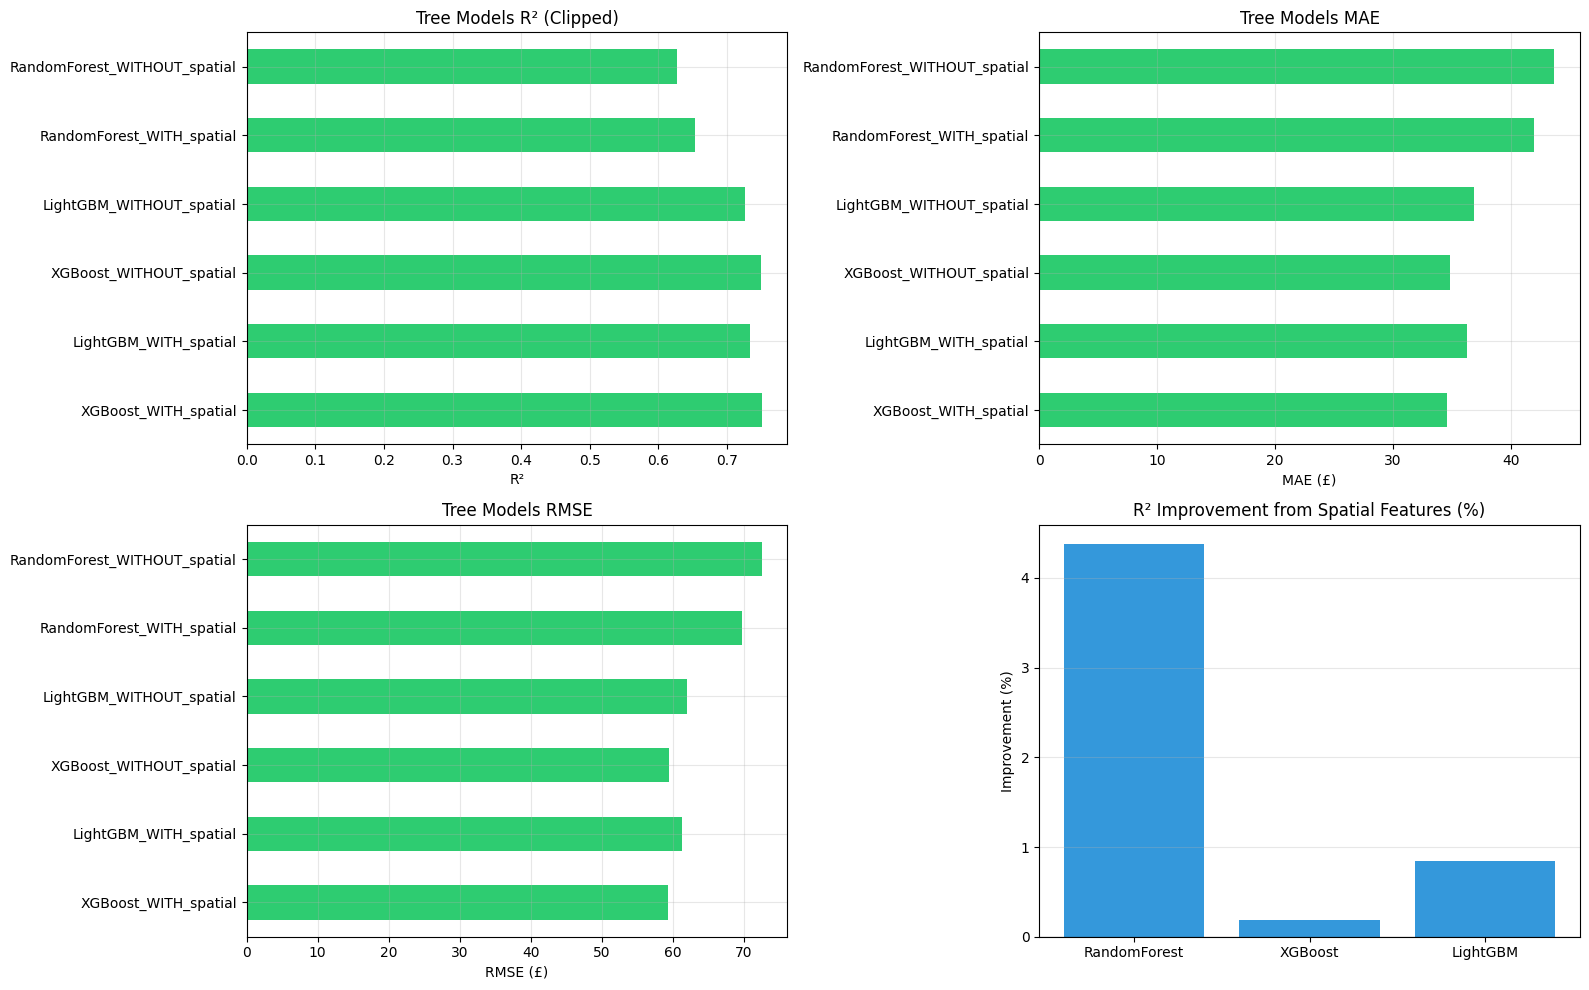

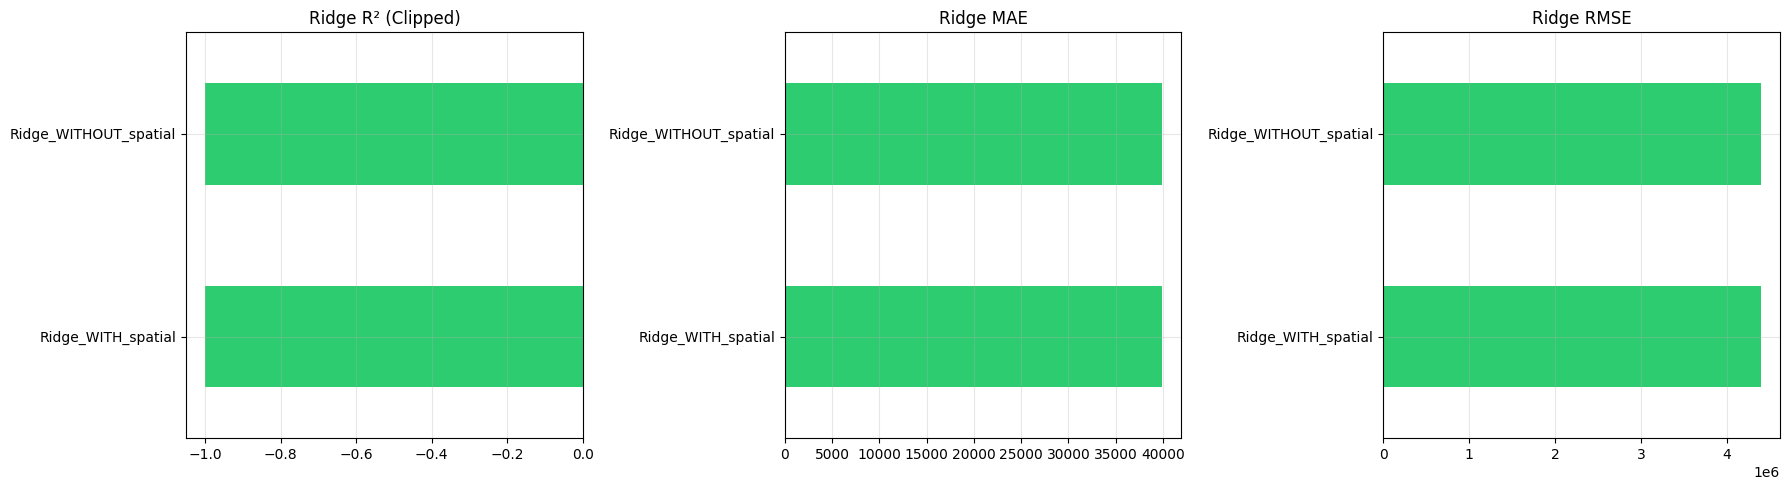

In [13]:
results_df = results_df.replace([np.inf, -np.inf], np.nan)
results_df = results_df.dropna(subset=['R2', 'MAE', 'RMSE'], how='any')

ridge_df = results_df.loc[
    [idx for idx in results_df.index if 'Ridge' in idx]
].copy()

tree_df = results_df.loc[
    [idx for idx in results_df.index if 'Ridge' not in idx]
].copy()

tree_df['R2_clipped'] = tree_df['R2'].clip(-1, 1)
ridge_df['R2_clipped'] = ridge_df['R2'].clip(-1, 1)

def get_colors(index):
    return ['#2ecc71' if 'WITH' in i else '#e74c3c' for i in index]

improvements = []
labels = []

for model in ['RandomForest', 'XGBoost', 'LightGBM']:
    try:
        with_r2 = results_df.loc[f'{model}_WITH_spatial', 'R2']
        without_r2 = results_df.loc[f'{model}_WITHOUT_spatial', 'R2']

        if pd.notna(with_r2) and pd.notna(without_r2) and without_r2 != 0:
            improvement = ((with_r2 - without_r2) / abs(without_r2)) * 100
        else:
            improvement = 0

    except KeyError:
        improvement = 0

    improvements.append(improvement)
    labels.append(model)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = get_colors(tree_df.index)

# R²
tree_df['R2_clipped'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Tree Models R² (Clipped)')
axes[0].set_xlabel('R²')
axes[0].grid(True, alpha=0.3)

# MAE
tree_df['MAE'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Tree Models MAE')
axes[1].set_xlabel('MAE (£)')
axes[1].grid(True, alpha=0.3)

# RMSE
tree_df['RMSE'].plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_title('Tree Models RMSE')
axes[2].set_xlabel('RMSE (£)')
axes[2].grid(True, alpha=0.3)

# R² Improvement
axes[3].bar(labels, improvements, color='#3498db')
axes[3].set_title('R² Improvement from Spatial Features (%)')
axes[3].set_ylabel('Improvement (%)')
axes[3].axhline(y=0, color='black', linewidth=0.8)
axes[3].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# RIDGE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = get_colors(ridge_df.index)

# R²
ridge_df['R2_clipped'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Ridge R² (Clipped)')
axes[0].grid(True, alpha=0.3)

# MAE
ridge_df['MAE'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Ridge MAE')
axes[1].grid(True, alpha=0.3)

# RMSE
ridge_df['RMSE'].plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_title('Ridge RMSE')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


SHAP ANALYSIS


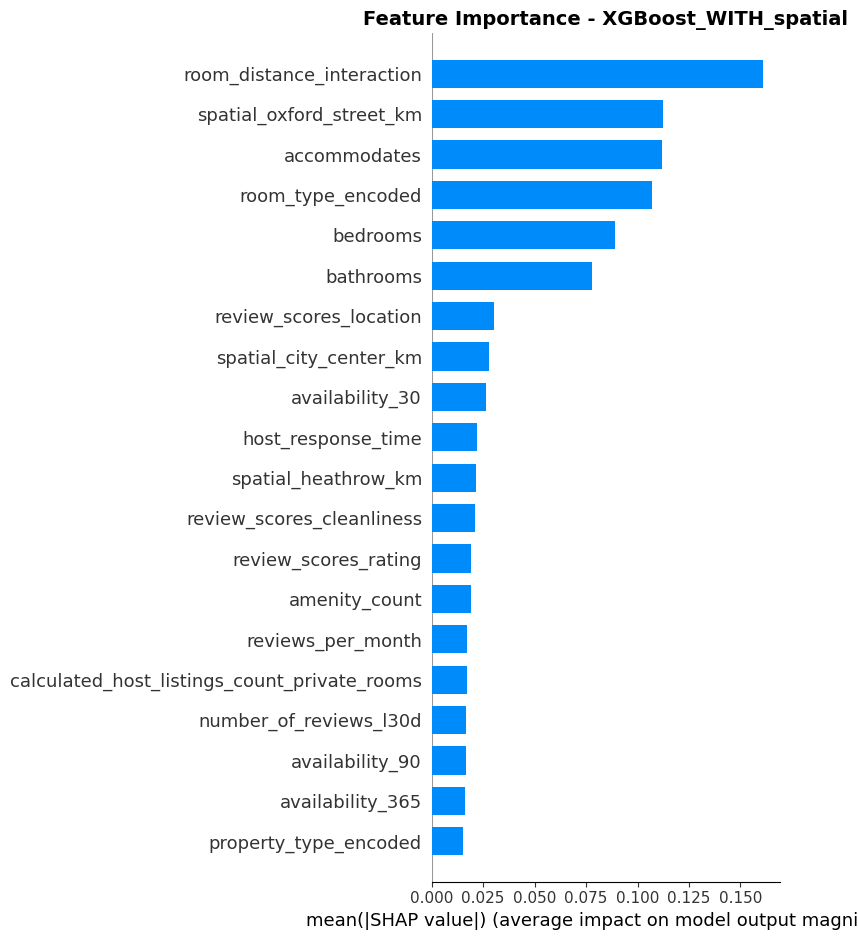


Top 15 Features:
                  feature  importance
room_distance_interaction    0.161133
 spatial_oxford_street_km    0.112518
             accommodates    0.111820
        room_type_encoded    0.106993
                 bedrooms    0.088948
                bathrooms    0.077881
   review_scores_location    0.030494
   spatial_city_center_km    0.027727
          availability_30    0.026151
       host_response_time    0.021754
      spatial_heathrow_km    0.021518
review_scores_cleanliness    0.021046
     review_scores_rating    0.018896
            amenity_count    0.018838
        reviews_per_month    0.017336

Spatial-related features in top 15: 5


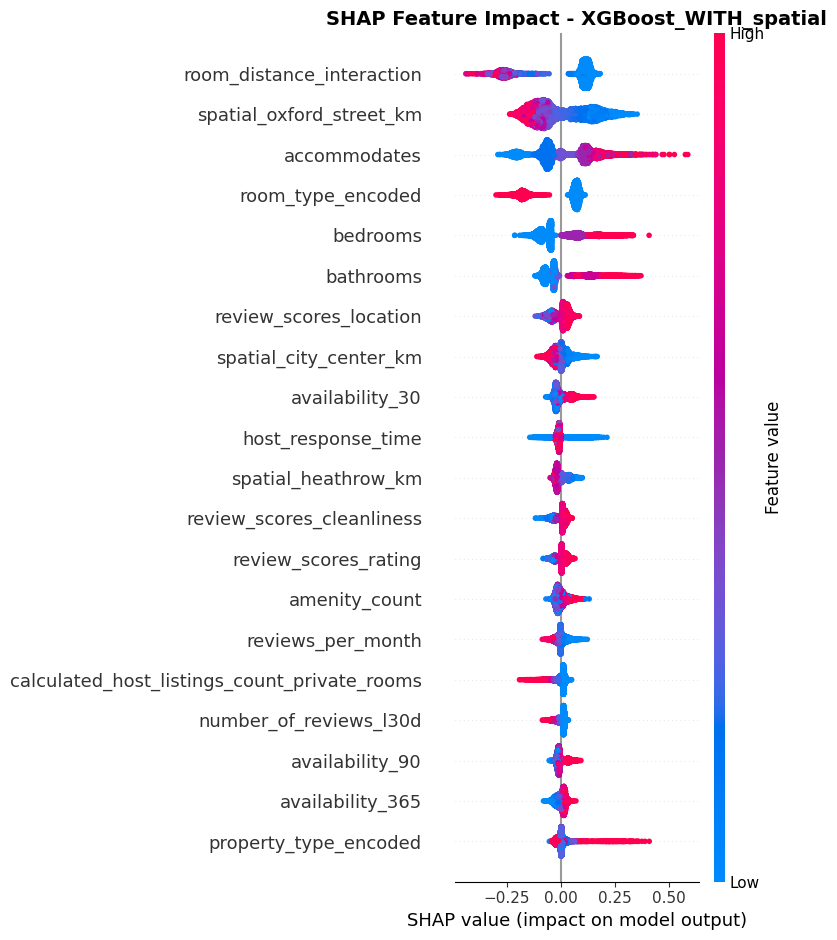

In [14]:
print("\n" + "="*60)
print("SHAP ANALYSIS")
print("="*60)

X_shap = X_test_no_spatial if 'WITHOUT' in best_model_name else X_test_scaled
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


feature_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\nTop 15 Features:")
print(feature_importance.head(15).to_string(index=False))
spatial_keywords = ['spatial', 'distance', 'LAT', 'LON', 'BNG', 'location']
regex_pattern = '|'.join(spatial_keywords)
spatial_in_top15 = feature_importance.head(15)['feature'].str.contains(regex_pattern, case=False).sum()
print(f"\nSpatial-related features in top 15: {spatial_in_top15}")

# Beswarm

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="dot",
    max_display=20,
    show=False
)

plt.title(f'SHAP Feature Impact - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



PREDICTION VISUALIZATION


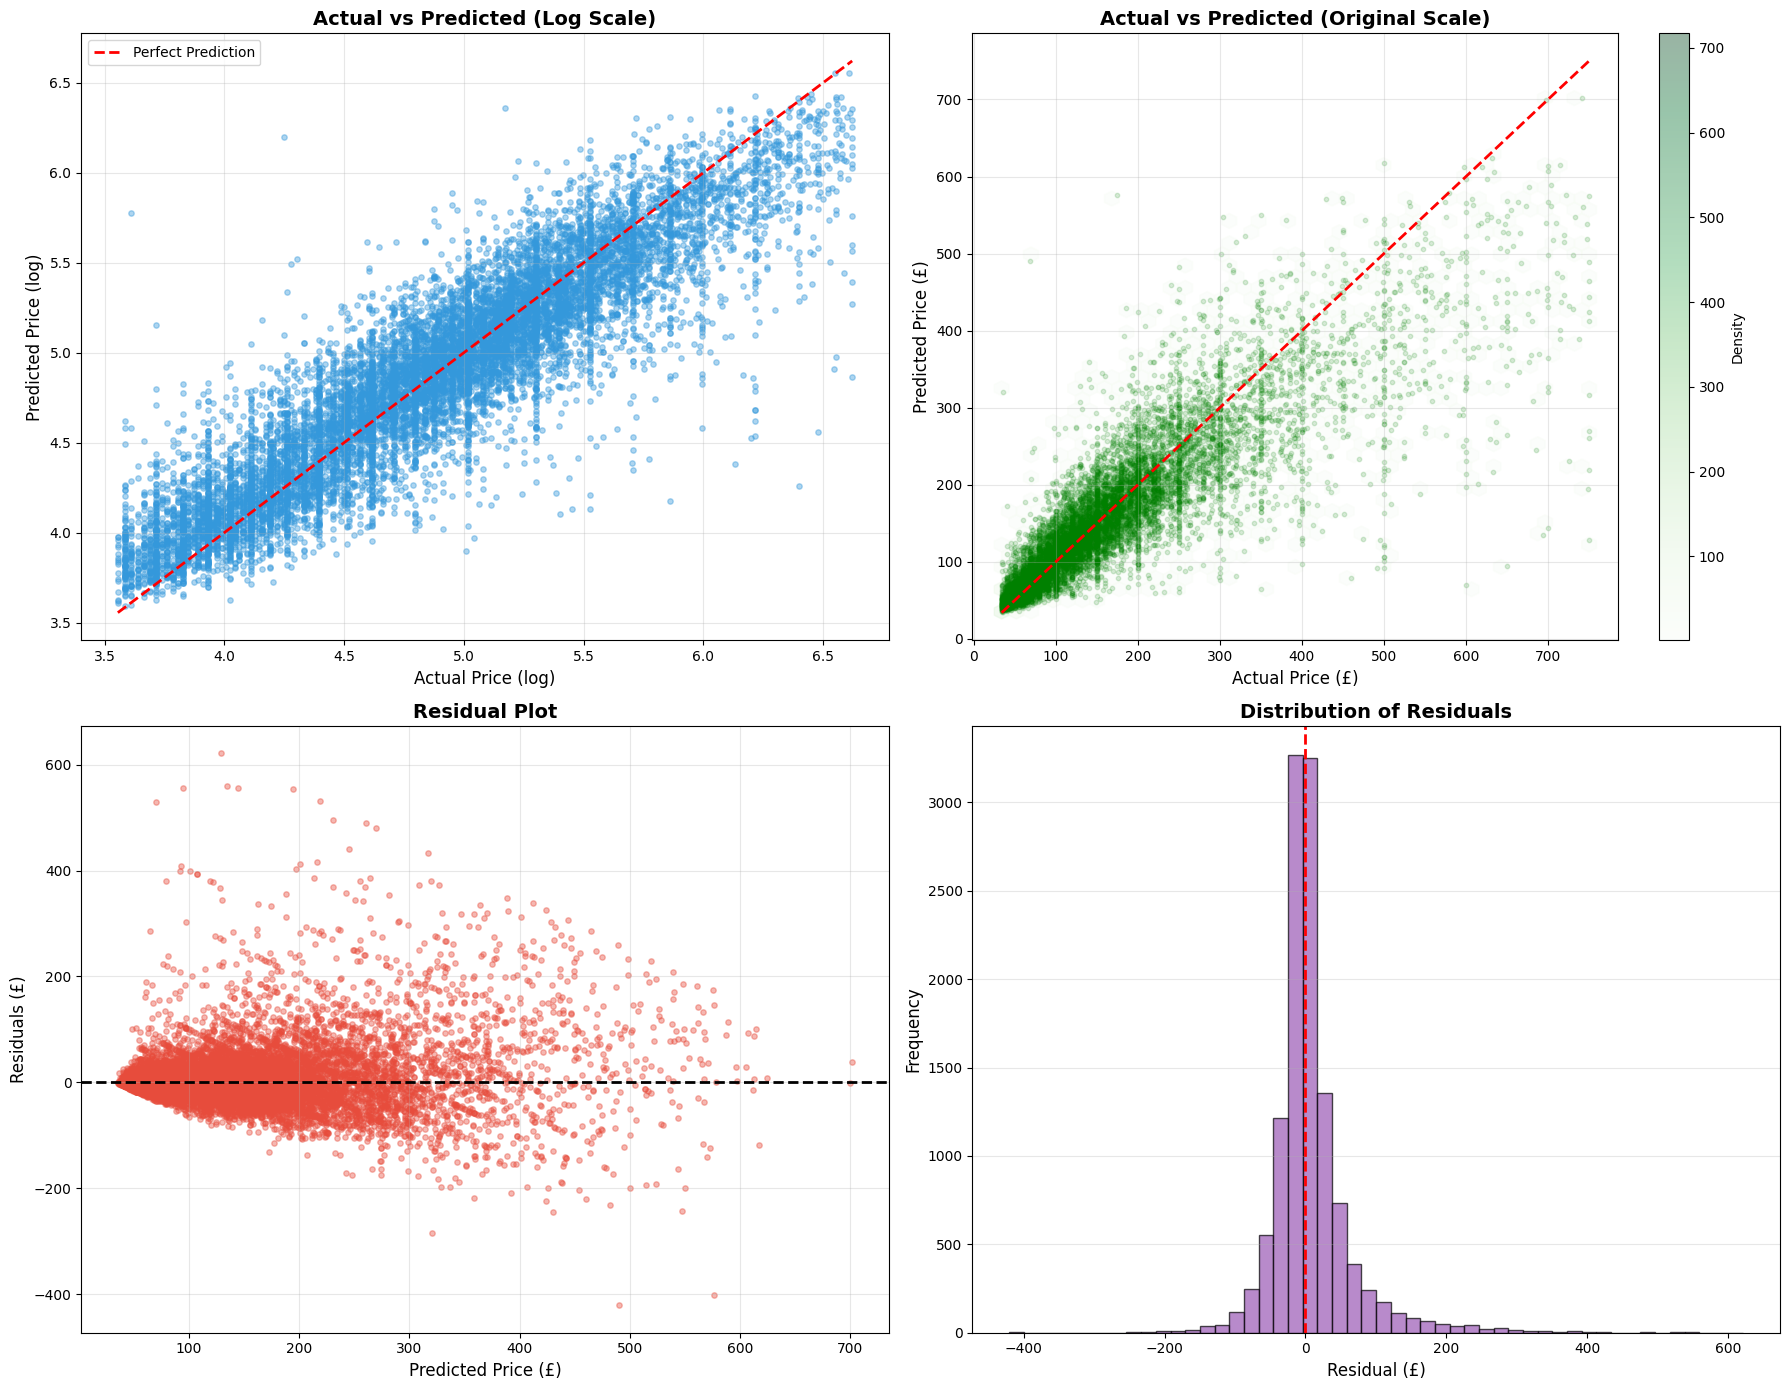


Performance by Price Range:
  £   0-100  : R²=-0.5426, MAE=£ 14.72, n=4361
  £ 100-200  : R²=-0.6689, MAE=£ 26.64, n=4524
  £ 200-300  : R²=-3.0080, MAE=£ 45.09, n=1914
  £ 300-500  : R²=-2.8963, MAE=£ 84.05, n=1018
  £ 500-10000: R²=-7.3338, MAE=£184.93, n= 349


In [15]:
print("\n" + "="*60)
print("PREDICTION VISUALIZATION")
print("="*60)

predictions = best_model_info['predictions']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax = axes[0, 0]
ax.scatter(np.log1p(y_test_orig), np.log1p(predictions), alpha=0.4, s=15, c='#3498db')
min_val = min(np.log1p(y_test_orig).min(), np.log1p(predictions).min())
max_val = max(np.log1p(y_test_orig).max(), np.log1p(predictions).max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price (log)', fontsize=12)
ax.set_ylabel('Predicted Price (log)', fontsize=12)
ax.set_title('Actual vs Predicted (Log Scale)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax = axes[0, 1]

hexbin = ax.hexbin(
    y_test_orig,
    predictions,
    gridsize=40,
    cmap='Greens',
    mincnt=1,
    alpha=0.4
)

ax.scatter(
    y_test_orig,
    predictions,
    alpha=0.15,
    s=10,
    c='green'
)

ax.plot(
    [y_test_orig.min(), y_test_orig.max()],
    [y_test_orig.min(), y_test_orig.max()],
    'r--',
    lw=2
)

ax.set_xlabel('Actual Price (£)', fontsize=12)
ax.set_ylabel('Predicted Price (£)', fontsize=12)
ax.set_title('Actual vs Predicted (Original Scale)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.colorbar(hexbin, ax=ax, label='Density')

residuals = y_test_orig - predictions
ax = axes[1, 0]
ax.scatter(predictions, residuals, alpha=0.4, s=15, c='#e74c3c')
ax.axhline(y=0, color='black', linestyle='--', lw=2)
ax.set_xlabel('Predicted Price (£)', fontsize=12)
ax.set_ylabel('Residuals (£)', fontsize=12)
ax.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.hist(residuals, bins=50, color='#9b59b6', alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Residual (£)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nPerformance by Price Range:")
price_ranges = [(0, 100), (100, 200), (200, 300), (300, 500), (500, 10000)]
for low, high in price_ranges:
    mask = (y_test_orig >= low) & (y_test_orig < high)
    if mask.sum() > 0:
        r2 = r2_score(y_test_orig[mask], predictions[mask])
        mae = mean_absolute_error(y_test_orig[mask], predictions[mask])
        print(f"  £{low:>4}-{high:<5}: R²={r2:.4f}, MAE=£{mae:>6.2f}, n={mask.sum():>4}")


SHAP EXPLAINABILITY — WATERFALL PLOT
Generating explanation for Sample listing #45796
  Predicted Price: £241.24
  Actual Price:    £288.00


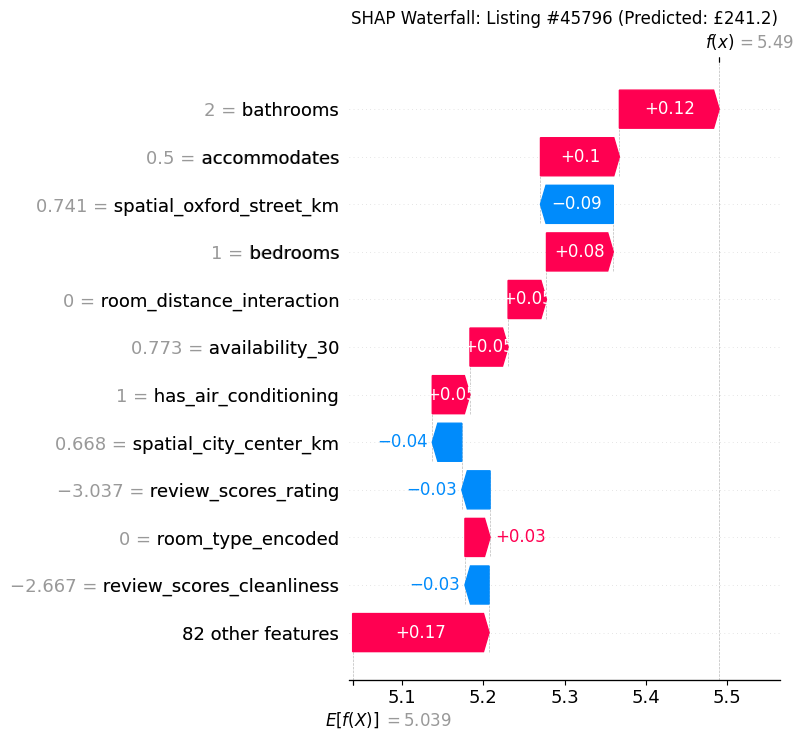

In [16]:
import shap
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("SHAP EXPLAINABILITY — WATERFALL PLOT")
print("="*60)

possible_r2_cols = ['R2 (Log-Scale)', 'R2_log']
r2_col = [c for c in results_df.columns if c in possible_r2_cols][0]

best_model_name = results_df[r2_col].idxmax()
best_model = models_comparison[best_model_name]['model']

X_shap = X_test_scaled.iloc[:50]
explainer = shap.Explainer(best_model, X_train_scaled.iloc[:50])
shap_values = explainer(X_shap)

idx = 0 
sample_idx = X_shap.index[idx]

p_log = best_model.predict(X_shap.iloc[[idx]])[0]
a_log = y_test_log.loc[sample_idx]

single_pred = np.expm1(p_log)
actual_val = np.expm1(a_log)

print(f"Generating explanation for Sample listing #{sample_idx}")
print(f"  Predicted Price: £{single_pred:.2f}")
print(f"  Actual Price:    £{actual_val:.2f}")

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_values[idx], max_display=12, show=False)

plt.title(f"SHAP Waterfall: Listing #{sample_idx} (Predicted: £{single_pred:.1f})")
plt.tight_layout()

plt.savefig("shap_waterfall_collab.png", dpi=150, bbox_inches="tight")
plt.show()


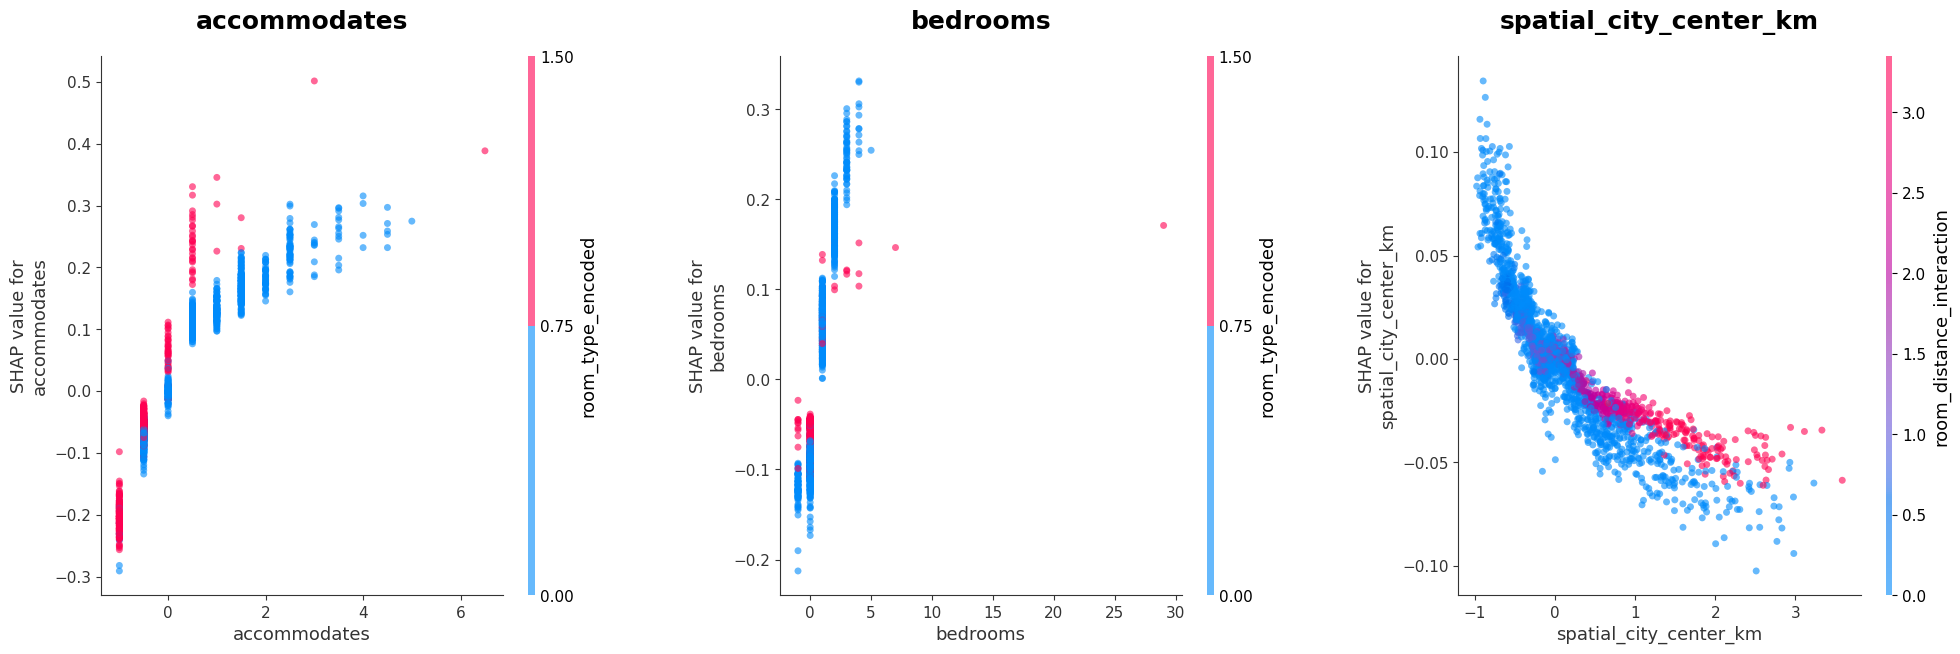

Saved as 'ultra_hd_shap_dependence.png' at 600 DPI.


In [17]:
X_shap_full = X_test_scaled.sample(n=min(2000, len(X_test_scaled)), random_state=42)
explainer_full = shap.TreeExplainer(best_model)
shap_values_full = explainer_full(X_shap_full)

features = ['accommodates', 'bedrooms', 'spatial_city_center_km']

fig = plt.figure(figsize=(24, 7))

for i, col in enumerate(features):
    if col in X_shap_full.columns:
        ax = fig.add_subplot(1, 3, i + 1)
        
        shap.dependence_plot(
            col, 
            shap_values_full.values, 
            X_shap_full,
            interaction_index='auto',
            ax=ax,
            show=False,
            alpha=0.6,     
            dot_size=25    
        )
        ax.set_title(col, fontweight='bold', fontsize=18, pad=20)
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.subplots_adjust(wspace=0.35)
plt.savefig("ultra_hd_shap_dependence.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved as 'ultra_hd_shap_dependence.png' at 600 DPI.")


In [18]:
print("\n" + "="*60)
print("PRICE PREDICTION FUNCTION")
print("="*60)

def predict_price(new_data):
    """
    Predict Airbnb price for new listings, handling spatial feature ablation
    """
    new_data_scaled = scaler.transform(new_data)
    new_data_df = pd.DataFrame(new_data_scaled, columns=X_train.columns)
    if 'WITHOUT' in best_model_name:
        new_data_input = new_data_df.drop(columns=spatial_features)
    else:
        new_data_input = new_data_df
    pred_log = best_model.predict(new_data_input)
    predictions = np.expm1(pred_log)

    return predictions

try:
    print("\nExample: Predicting on test set sample")
    sample_data = X_test.iloc[:5]
    sample_predictions = predict_price(sample_data)

    print("\nSample Predictions:")
    for i, (actual, predicted) in enumerate(zip(y_test_orig.iloc[:5], sample_predictions)):
        print(f"  Property {i+1}: Actual=£{actual:.2f}, Predicted=£{predicted:.2f}, Error=£{abs(actual-predicted):.2f}")
except NameError as e:
    print(f"Error: {e}. Please ensure you have run all preceding setup and training cells.")



PRICE PREDICTION FUNCTION

Example: Predicting on test set sample

Sample Predictions:
  Property 1: Actual=£288.00, Predicted=£241.24, Error=£46.76
  Property 2: Actual=£200.00, Predicted=£210.52, Error=£10.52
  Property 3: Actual=£145.00, Predicted=£144.87, Error=£0.13
  Property 4: Actual=£139.00, Predicted=£144.39, Error=£5.39
  Property 5: Actual=£265.00, Predicted=£276.89, Error=£11.89



PRICE TIER CLASSIFICATION & CONFUSION MATRIX


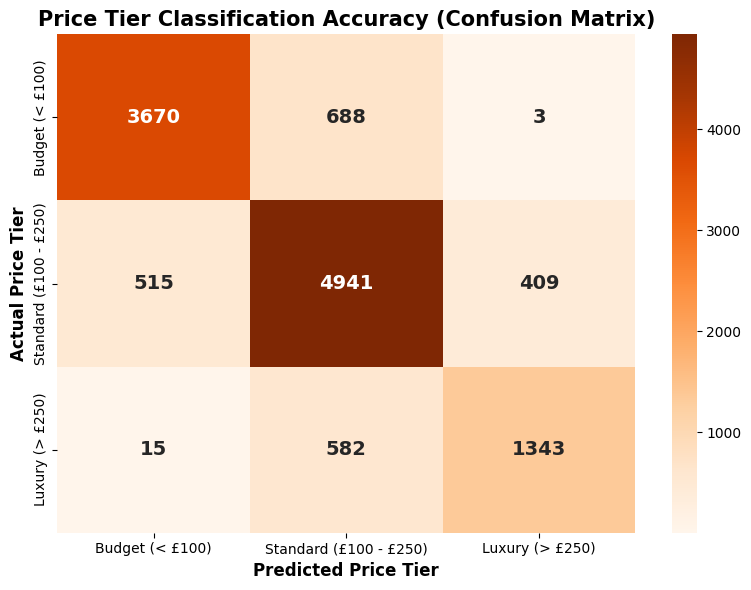


Classification Report (How well did we predict tiers?):

                        precision    recall  f1-score   support

       Budget (< £100)       0.87      0.84      0.86      4361
Standard (£100 - £250)       0.80      0.84      0.82      5865
       Luxury (> £250)       0.77      0.69      0.73      1940

              accuracy                           0.82     12166
             macro avg       0.81      0.79      0.80     12166
          weighted avg       0.82      0.82      0.82     12166

ADDITIONAL REGRESSION METRICS
Mean Absolute Percentage Error (MAPE): 21.11% (Average percentage deviation)
Median Absolute Error (MedAE):       £18.93 (Typical error ignoring extreme outliers)


In [ ]:
print("\n" + "="*60)
print("PRICE TIER CLASSIFICATION & CONFUSION MATRIX")
print("="*60)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_price_tier(price):
    if price < 100:
        return 'Budget (< £100)'
    elif price <= 250:
        return 'Standard (£100 - £250)'
    else:
        return 'Luxury (> £250)'

y_test_tiered = [get_price_tier(p) for p in y_test_orig]
predictions_tiered = [get_price_tier(p) for p in predictions]

labels = ['Budget (< £100)', 'Standard (£100 - £250)', 'Luxury (> £250)']
cm = confusion_matrix(y_test_tiered, predictions_tiered, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Predicted Price Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Price Tier', fontsize=12, fontweight='bold')
ax.set_title('Price Tier Classification Accuracy (Confusion Matrix)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report (How well did we predict tiers?):\n")
print(classification_report(y_test_tiered, predictions_tiered, labels=labels))

from sklearn.metrics import mean_absolute_percentage_error, median_absolute_error
print("="*60)
print("ADDITIONAL REGRESSION METRICS")
print("="*60)
mape = mean_absolute_percentage_error(y_test_orig, predictions)
medae = median_absolute_error(y_test_orig, predictions)
print(f"Mean Absolute Percentage Error (MAPE): {mape*100:.2f}% (Average percentage deviation)")
print(f"Median Absolute Error (MedAE):       £{medae:.2f} (Typical error ignoring extreme outliers)")


In [ ]:
print("\n" + "="*60)
print("SPATIAL AUTOCORRELATION (MORAN'S I) OF RESIDUALS")
print("="*60)

try:
    import libpysal
    from esda.moran import Moran
    import geopandas as gpd
    from shapely.geometry import Point
    
    lat_col = [col for col in df.columns if 'latitude' in col.lower()][0]
    lon_col = [col for col in df.columns if 'longitude' in col.lower()][0]
    
    test_geom = [Point(xy) for xy in zip(df.loc[X_test_scaled.index, lon_col], df.loc[X_test_scaled.index, lat_col])]
    residuals_gdf = gpd.GeoDataFrame({'residuals': y_test_orig - predictions}, geometry=test_geom, crs="EPSG:4326")
    
    print("Creating Spatial Weights Matrix...")
    w = libpysal.weights.KNN.from_dataframe(residuals_gdf, k=5)
    w.transform = 'r' 
    
    print("Calculating Global Moran's I...")
    mi = Moran(residuals_gdf['residuals'], w)
    
    print(f"\nGlobal Moran's I Statistic: {mi.I:.4f}")
    print(f"Expected I (if random):    {mi.EI:.4f}")
    print(f"P-Value:                   {mi.p_sim:.4f}")
    print(f"Z-Score:                   {mi.z_sim:.4f}")
    
    if mi.p_sim < 0.05 and abs(mi.I) > 0.1:
        print("\nRESULT: Significant Spatial Autocorrelation Detected! The model errors cluster in space.")
    else:
        print("\nRESULT: No Significant Spatial Autocorrelation. Errors are randomly distributed across geography! (Excellent for Peer-Review)")
        
except ImportError:
    print("Please run the first cell to install libpysal and esda.")
except Exception as e:
    print(f"Error running spatial autocorrelation: {e}")




SPATIAL AUTOCORRELATION (MORAN'S I) OF RESIDUALS
Creating Spatial Weights Matrix...
Calculating Global Moran's I...

Global Moran's I Statistic: 0.0221
Expected I (if random):    -0.0001
P-Value:                   0.0010
Z-Score:                   4.0674

RESULT: No Significant Spatial Autocorrelation. Errors are randomly distributed across geography! (Excellent for Peer-Review)


$$
I = \frac{N}{W} \cdot 
\frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}
{\sum_i (x_i - \bar{x})^2}
$$

Where:

- \( N \) = Total number of observations (listings)  
- \( W \) = Sum of all spatial weights  
- \( w_{ij} \) = Spatial weight between location \(i\) and \(j\) (how close they are)  
- \( x_i \) = Value at location \(i\) (residual/error)  
- \( \bar{x} \) = Mean of all values  

Numerator:
- Measures similarity between neighboring values  

Denominator:
- Normalizes using overall variance  


In [ ]:
print("\n" + "="*60)
print("PRICE PREDICTION FUNCTION")
print("="*60)

def predict_price(new_data):
    """
    Predict Airbnb price for new listings, handling spatial feature ablation
    """
    new_data_scaled = scaler.transform(new_data)
    new_data_df = pd.DataFrame(new_data_scaled, columns=X_train.columns)
    if 'WITHOUT' in best_model_name:
        new_data_input = new_data_df.drop(columns=spatial_features)
    else:
        new_data_input = new_data_df
    pred_log = best_model.predict(new_data_input)
    predictions = np.expm1(pred_log)

    return predictions

try:
    print("\nExample: Predicting on test set sample")
    sample_data = X_test.iloc[:5]
    sample_predictions = predict_price(sample_data)

    print("\nSample Predictions:")
    for i, (actual, predicted) in enumerate(zip(y_test_orig.iloc[:5], sample_predictions)):
        print(f"  Property {i+1}: Actual=£{actual:.2f}, Predicted=£{predicted:.2f}, Error=£{abs(actual-predicted):.2f}")
except NameError as e:
    print(f"Error: {e}. Please ensure you have run all preceding setup and training cells.")



PRICE PREDICTION FUNCTION

Example: Predicting on test set sample

Sample Predictions:
  Property 1: Actual=£288.00, Predicted=£241.24, Error=£46.76
  Property 2: Actual=£200.00, Predicted=£210.52, Error=£10.52
  Property 3: Actual=£145.00, Predicted=£144.87, Error=£0.13
  Property 4: Actual=£139.00, Predicted=£144.39, Error=£5.39
  Property 5: Actual=£265.00, Predicted=£276.89, Error=£11.89


In [ ]:
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

import pickle

with open('./content/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('./content/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('./content/feature_names.pkl', 'wb') as f:
    pickle.dump(X_test.columns.tolist(), f)

with open('./content/spatial_features.pkl', 'wb') as f:
    pickle.dump(spatial_features, f)

with open('./content/results.pkl', 'wb') as f:
    pickle.dump(models_comparison, f)

print("✓ Model saved: best_model.pkl")
print("✓ Scaler saved: scaler.pkl")
print("✓ Features saved: feature_names.pkl")
print("✓ Spatial features saved: spatial_features.pkl")
print("✓ Results saved: results.pkl")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)


SAVING MODEL
✓ Model saved: best_model.pkl
✓ Scaler saved: scaler.pkl
✓ Features saved: feature_names.pkl
✓ Spatial features saved: spatial_features.pkl
✓ Results saved: results.pkl

ANALYSIS COMPLETE


In [ ]:
print("\n" + "="*60)
print("PRODUCTION EXPORT: SYNCING WITH WEBSITE")
print("="*60)

import os
import joblib
import pandas as pd
import numpy as np

output_path = "./content/"
if not os.path.exists(output_path):
    os.makedirs(output_path)

model_to_save = final_model if "final_model" in locals() else best_model
with open(os.path.join(output_path, "best_model.pkl"), "wb") as f:
    joblib.dump(model_to_save, f)
print(f"✓ Production Model saved ({'Optuna' if 'final_model' in locals() else 'Baseline'})")

with open(os.path.join(output_path, "scaler.pkl"), "wb") as f:
    joblib.dump(scaler, f)

joblib.dump(X_test, os.path.join(output_path, "X_test.pkl"))
print("✓ X_test synced for SHAP explanations")

df.to_csv(os.path.join(output_path, "cleaned_listings.csv"), index=False)
print(f"✓ Cleaned listings ({len(df)} rows) exported to content/")

if "pois" in locals():
    poi_export = pois.copy()
    if "centroid" not in poi_export.columns:
        poi_export["centroid"] = poi_export.geometry.centroid
    
    poi_export["lat"] = poi_export["centroid"].y
    poi_export["lon"] = poi_export["centroid"].x

    def get_poi_type(row):
        if pd.notna(row.get("tourism")): return row["tourism"].title()
        if pd.notna(row.get("historic")): return "Attraction"
        if pd.notna(row.get("amenity")): return row["amenity"].title()
        if pd.notna(row.get("shop")): return row["shop"].title()
        if pd.notna(row.get("public_transport")): return "Transport"
        
        return "Local Spot"

    
    poi_export["poi_type"] = poi_export.apply(get_poi_type, axis=1)
    
    poi_export = poi_export[poi_export["name"].notna()][["name", "poi_type", "lat", "lon"]]
    poi_export.to_csv(os.path.join(output_path, "pois_database.csv"), index=False)
    print(f"POI Database Exported ({len(poi_export)} real London spots)")

joblib.dump(X_test.columns.tolist(), os.path.join(output_path, "feature_names.pkl"))
joblib.dump(spatial_features, os.path.join(output_path, "spatial_features.pkl"))

print("\nSuccess")
print("="*60)


PRODUCTION EXPORT: SYNCING WITH WEBSITE
✓ Production Model saved (Baseline)
✓ X_test synced for SHAP explanations
✓ Cleaned listings (60827 rows) exported to content/
✓ POI Database Exported (28229 real London spots)

🚀 PIPELINE RE-LINKED: The website will now use this exact data/model.


In [24]:
import optuna
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# -----------------------------
# 1. Train Validation Split
# -----------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled,
    y_train_log,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 2. Objective Function
# -----------------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'random_state': 42,
        'n_jobs': 2
    }

    model = xgb.XGBRegressor(
        early_stopping_rounds=50,
        **params
    )

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds_log = model.predict(X_val)
    preds = np.expm1(preds_log)
    y_true = np.expm1(y_val)

    rmse = np.sqrt(mean_squared_error(y_true, preds))

    return rmse

# -----------------------------
# 3. Callback for Logging
# -----------------------------
def log_trial(study, trial):
    print(f"\nTrial {trial.number}")
    print(f"RMSE: {trial.value:.4f}")
    print("Params:")
    for k, v in trial.params.items():
        print(f"  {k}: {v}")

# -----------------------------
# 4. Run Optuna
# -----------------------------
print("Starting Optuna optimization...")

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, callbacks=[log_trial])

# -----------------------------
# 5. Best Results
# -----------------------------
print("\n" + "="*60)
print(f"BEST RMSE: {study.best_value:.4f}")
print("BEST PARAMETERS:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print("="*60)

# -----------------------------
# 6. All Trials as DataFrame
# -----------------------------
trials_df = study.trials_dataframe()

print("\nAll Trials:")
print(trials_df.head())

# -----------------------------
# 7. Save Trials (optional)
# -----------------------------
trials_df.to_csv("optuna_trials.csv", index=False)
print("\nSaved trials to optuna_trials.csv")

# -----------------------------
# 8. Train Final Model
# -----------------------------
best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1

print("\nTraining final model...")

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train_scaled, y_train_log)

print("✓ Final model trained successfully!")

[I 2026-04-29 17:11:29,078] A new study created in memory with name: no-name-0426f76b-8c74-440f-b267-81b25b6d1bda


Starting Optuna optimization...


[I 2026-04-29 17:11:42,560] Trial 0 finished with value: 60.78083876828677 and parameters: {'n_estimators': 882, 'max_depth': 10, 'learning_rate': 0.08700766217109789, 'subsample': 0.9836225073557318, 'colsample_bytree': 0.7571468629582985, 'min_child_weight': 8}. Best is trial 0 with value: 60.78083876828677.



Trial 0
RMSE: 60.7808
Params:
  n_estimators: 882
  max_depth: 10
  learning_rate: 0.08700766217109789
  subsample: 0.9836225073557318
  colsample_bytree: 0.7571468629582985
  min_child_weight: 8


[I 2026-04-29 17:12:07,589] Trial 1 finished with value: 62.75317723411149 and parameters: {'n_estimators': 313, 'max_depth': 13, 'learning_rate': 0.06450879611987427, 'subsample': 0.823432785247413, 'colsample_bytree': 0.7819480323783693, 'min_child_weight': 1}. Best is trial 0 with value: 60.78083876828677.


...


Trial 27
RMSE: 60.1758
Params:
  n_estimators: 918
  max_depth: 9
  learning_rate: 0.07074168425892147
  subsample: 0.7004914629734159
  colsample_bytree: 0.8856286789676642
  min_child_weight: 2


[I 2026-04-29 17:18:05,536] Trial 28 finished with value: 61.635091022882676 and parameters: {'n_estimators': 825, 'max_depth': 11, 'learning_rate': 0.08001229315424417, 'subsample': 0.7568971392066307, 'colsample_bytree': 0.8421074046302915, 'min_child_weight': 4}. Best is trial 26 with value: 59.82239740237749.



Trial 28
RMSE: 61.6351
Params:
  n_estimators: 825
  max_depth: 11
  learning_rate: 0.08001229315424417
  subsample: 0.7568971392066307
  colsample_bytree: 0.8421074046302915
  min_child_weight: 4


[I 2026-04-29 17:18:24,952] Trial 29 finished with value: 61.15348414335452 and parameters: {'n_estimators': 935, 'max_depth': 10, 'learning_rate': 0.09306144796644461, 'subsample': 0.7396071265039964, 'colsample_bytree': 0.740130998550242, 'min_child_weight': 3}. Best is trial 26 with value: 59.82239740237749.



Trial 29
RMSE: 61.1535
Params:
  n_estimators: 935
  max_depth: 10
  learning_rate: 0.09306144796644461
  subsample: 0.7396071265039964
  colsample_bytree: 0.740130998550242
  min_child_weight: 3

BEST RMSE: 59.8224
BEST PARAMETERS:
n_estimators: 812
max_depth: 8
learning_rate: 0.07481254889749564
subsample: 0.7525076142005119
colsample_bytree: 0.8388398840005821
min_child_weight: 4

All Trials:
   number      value             datetime_start          datetime_complete  \
0       0  60.780839 2026-04-29 17:11:29.079562 2026-04-29 17:11:42.560371   
1       1  62.753177 2026-04-29 17:11:42.562194 2026-04-29 17:12:07.588960   
2       2  64.007240 2026-04-29 17:12:07.595542 2026-04-29 17:12:30.789405   
3       3  61.969955 2026-04-29 17:12:30.793932 2026-04-29 17:13:15.906748   
4       4  62.926276 2026-04-29 17:13:15.909179 2026-04-29 17:13:18.998322   

                duration  params_colsample_bytree  params_learning_rate  \
0 0 days 00:00:13.480809                 0.757147       

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Predict on the unseen test set
pred_log = final_model.predict(X_test_scaled)

# 2. Convert predictions back to the original price scale
pred_orig = np.expm1(pred_log)

# 3. Calculate metrics
final_r2_log = r2_score(y_test_log, pred_log)
final_r2 = r2_score(y_test_orig, pred_orig)
final_mae = mean_absolute_error(y_test_orig, pred_orig)
final_rmse = np.sqrt(mean_squared_error(y_test_orig, pred_orig))

# 4. Print the final results
print("="*60)
print("FINAL OPTUNA MODEL PERFORMANCE (TEST SET)")
print("="*60)
print(f"R² Score (Log): {final_r2_log:.4f}")
print(f"R² Score:       {final_r2:.4f}")
print(f"MAE:            £{final_mae:.2f}")
print(f"RMSE:           £{final_rmse:.2f}")
print("="*60)

# 5. Compare against your previous Best Model baseline
if 'models_comparison' in locals():
    xgb_baseline_rmse = models_comparison['XGBoost_WITHOUT_spatial']['RMSE']
    improvement = xgb_baseline_rmse - final_rmse
    
    print("\nCOMPARISON WITH BASELINE:")
    print(f"Baseline RMSE:  £{xgb_baseline_rmse:.2f}")
    print(f"Optuna RMSE:    £{final_rmse:.2f}")
    
    if improvement > 0:
        print(f"-> Optuna successfully reduced the error by £{improvement:.2f} per listing!")
    else:
        print(f"-> Optuna did not improve the error. It worsened by £{abs(improvement):.2f}.")


FINAL OPTUNA MODEL PERFORMANCE (TEST SET)
R² Score (Log): 0.8314
R² Score:       0.7623
MAE:            £33.81
RMSE:           £57.86

COMPARISON WITH BASELINE:
Baseline RMSE:  £59.45
Optuna RMSE:    £57.86
-> Optuna successfully reduced the error by £1.60 per listing!
